##  Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

##  Loading Data

In [2]:
FILE_PATH = 'apms-2014-ch-02-tabs.xls'
ENGINE = 'xlrd'

raw = {
    'cisr_age_sex'   : pd.read_excel(FILE_PATH, sheet_name='2.1',   engine=ENGINE, header=None),
    'cisr_trend'     : pd.read_excel(FILE_PATH, sheet_name='2.2',   engine=ENGINE, header=None),
    'cmd_age_sex'    : pd.read_excel(FILE_PATH, sheet_name='2.3',   engine=ENGINE, header=None),
    'cmd_ethnicity'  : pd.read_excel(FILE_PATH, sheet_name='2.7',   engine=ENGINE, header=None),
    'cmd_household'  : pd.read_excel(FILE_PATH, sheet_name='2.8',   engine=ENGINE, header=None),
    'cmd_employment' : pd.read_excel(FILE_PATH, sheet_name='2.9 ',  engine=ENGINE, header=None),
    'cmd_benefit'    : pd.read_excel(FILE_PATH, sheet_name='2.10',  engine=ENGINE, header=None),
    'cmd_region'     : pd.read_excel(FILE_PATH, sheet_name='2.11',  engine=ENGINE, header=None),
    'cmd_smoking'    : pd.read_excel(FILE_PATH, sheet_name='2.12',  engine=ENGINE, header=None),
}

print('Sheets loaded successfully:')
for k, v in raw.items():
    print(f'  {k:20s} → {v.shape[0]} rows × {v.shape[1]} cols')

Sheets loaded successfully:
  cisr_age_sex         → 46 rows × 9 cols
  cisr_trend           → 45 rows × 33 cols
  cmd_age_sex          → 43 rows × 9 cols
  cmd_ethnicity        → 74 rows × 6 cols
  cmd_household        → 42 rows × 9 cols
  cmd_employment       → 72 rows × 5 cols
  cmd_benefit          → 77 rows × 7 cols
  cmd_region           → 75 rows × 10 cols
  cmd_smoking          → 72 rows × 5 cols


##  Parsing tables into clean DataFrames

In [3]:
BANDS  = ['0–5', '6–11', '12–17', '18+']
AGES   = ['16–24','25–34','35–44','45–54','55–64','65–74','75+','All']
_r = raw['cisr_age_sex']
cisr = pd.DataFrame(index=BANDS)
for label, rows in [('Men',   [6,7,10,11]),
                     ('Women', [16,17,20,21]),
                     ('All',   [26,27,30,31])]:
    data = _r.iloc[rows, 1:9].values.astype(float)
    for bi, band in enumerate(BANDS):
        for ai, age in enumerate(AGES):
            cisr.loc[band, f'{label}_{age}'] = data[bi, ai]
def cisr_for(sex):
    cols = [f'{sex}_{a}' for a in AGES]
    return cisr[cols].rename(columns={f'{sex}_{a}': a for a in AGES})

cisr_men   = cisr_for('Men')
cisr_women = cisr_for('Women')
cisr_all   = cisr_for('All')

print('CIS-R by Age & Sex (All adults):'); print(cisr_all.round(1)); print()

CIS-R by Age & Sex (All adults):
       16–24  25–34  35–44  45–54  55–64  65–74   75+   All
0–5     67.1   66.3   66.4   65.3   66.3   76.6  77.6  68.6
6–11    15.5   16.5   15.7   16.7   16.7   13.2  14.3  15.7
12–17    7.8    9.0    8.1    8.2    7.8    5.9   4.7   7.6
18+      9.5    8.2    9.8    9.8    9.2    4.2   3.3   8.1



In [4]:
DISORDERS = ['GAD','Depression','Phobias','OCD','Panic','CMD-NOS','Any CMD']
_d = raw['cmd_age_sex']
cmd_age = pd.DataFrame(
    _d.iloc[24:31, 1:9].values.astype(float),
    index=DISORDERS, columns=AGES
)
cmd_men = pd.DataFrame(
    _d.iloc[6:13, 1:9].values.astype(float),
    index=DISORDERS, columns=AGES
)
cmd_women = pd.DataFrame(
    _d.iloc[15:22, 1:9].values.astype(float),
    index=DISORDERS, columns=AGES
)
print('CMD by Disorder × Age (All adults):'); print(cmd_age.round(1)); print()

CMD by Disorder × Age (All adults):
            16–24  25–34  35–44  45–54  55–64  65–74  75+   All
GAD           6.3    6.1    6.9    7.3    6.4    4.0  2.5   5.9
Depression    2.3    3.5    4.1    4.5    4.3    2.1  1.3   3.3
Phobias       3.3    3.3    3.0    2.7    2.3    0.6  0.5   2.4
OCD           1.8    1.4    1.6    1.6    1.5    0.3  0.3   1.3
Panic         1.2    0.5    0.3    0.5    0.5    0.7  0.6   0.6
CMD-NOS       8.4    9.1    8.2    8.7    8.1    5.2  4.9   7.8
Any CMD      18.9   19.0   19.3   19.1   18.0   11.5  8.8  17.0



In [5]:
ETH = ['White British','White Other','Black/Black Br.','Asian/Asian Br.','Mixed/Other']
_e = raw['cmd_ethnicity']
cmd_eth = pd.DataFrame(
    _e.iloc[25:31, 1:6].values.astype(float),
    index=DISORDERS[:-1], columns=ETH
)
cmd_eth.loc['Any CMD'] = _e.iloc[31, 1:6].values.astype(float)
print('CMD by Ethnicity (All adults):'); print(cmd_eth.round(1)); print()

CMD by Ethnicity (All adults):
            White British  White Other  Black/Black Br.  Asian/Asian Br.  \
GAD                   6.1          4.0              6.5              5.8   
Depression            3.4          2.4              5.0              2.9   
Phobias               2.4          1.0              3.7              3.3   
OCD                   1.2          2.3              2.5              1.5   
Panic                 0.5          0.1              1.5              1.1   
CMD-NOS               7.6          7.2             13.2              7.1   
Any CMD              16.9         14.4             24.0             16.5   

            Mixed/Other  
GAD                 3.1  
Depression          2.6  
Phobias             3.2  
OCD                 0.8  
Panic               1.1  
CMD-NOS            11.2  
Any CMD            19.8  



In [6]:
EMP_GROUPS = ['Employed FT','Employed PT','Unemployed','Econ. Inactive']
_emp = raw['cmd_employment']

cmd_emp = pd.DataFrame(
    _emp.iloc[25:32, 1:5].values.astype(float),
    index=DISORDERS, columns=EMP_GROUPS
)
print('CMD by Employment (All adults):'); print(cmd_emp.round(1)); print()

SMOKE_GROUPS = ['Non-smoker','Ex-smoker','1–14/day','15+/day']
_s = raw['cmd_smoking']

cmd_smoke = pd.DataFrame(
    _s.iloc[25:32, 1:5].values.astype(float),
    index=DISORDERS, columns=SMOKE_GROUPS
)
print('CMD by Smoking (All adults):'); print(cmd_smoke.round(1))

CMD by Employment (All adults):
            Employed FT  Employed PT  Unemployed  Econ. Inactive
GAD                 4.8          5.8         6.3            11.6
Depression          1.8          2.1         6.6             9.3
Phobias             1.4          1.4         5.3             7.2
OCD                 0.9          1.5         2.1             3.0
Panic               0.2          0.5         3.0             1.1
CMD-NOS             7.2          8.6         8.4            11.5
Any CMD            14.4         16.5        25.2            30.3

CMD by Smoking (All adults):
            Non-smoker  Ex-smoker  1–14/day  15+/day
GAD                4.6        4.9       9.3     13.8
Depression         2.4        2.6       5.0      9.9
Phobias            1.6        1.8       4.4      6.7
OCD                0.8        1.0       2.5      3.7
Panic              0.6        0.6       0.6      0.7
CMD-NOS            6.8        6.8      11.2     12.8
Any CMD           14.2       14.7      24.8    

In [7]:
REGIONS = ['NE','NW','Yorks','E.Mids','W.Mids','East','London','SE','SW']
_r11 = raw['cmd_region']
cmd_region = pd.DataFrame(
    _r11.iloc[25:32, 1:10].values.astype(float),
    index=DISORDERS, columns=REGIONS
)
print('CMD by Region (All adults):'); print(cmd_region.round(1))

CMD by Region (All adults):
              NE    NW  Yorks  E.Mids  W.Mids  East  London    SE    SW
GAD          7.2   7.1    4.9     5.3     6.1   6.5     5.8   5.4   5.4
Depression   3.3   4.6    2.7     3.3     3.8   2.6     3.3   2.3   4.1
Phobias      2.6   3.1    2.4     1.3     3.1   1.4     2.7   2.0   2.8
OCD          1.0   1.0    0.8     2.7     1.1   1.3     2.2   0.6   1.3
Panic        0.1   1.4    0.5     0.4     0.4   0.2     0.7   0.3   1.0
CMD-NOS      5.7   8.0    8.1     8.3     9.5   5.7     9.4   5.6   9.2
Any CMD     16.2  19.0   16.2    16.7    18.6  14.1    18.9  13.6  19.9


In [8]:
BAND_EDGES = [0, 6, 12, 18, 30]   # CIS-R band boundaries

def reconstruct_obs(band_pcts, n=400):
    pcts = np.array(band_pcts) / 100.0
    obs  = []
    for lo, hi, p in zip(BAND_EDGES[:-1], BAND_EDGES[1:], pcts):
        k = max(1, int(round(p * n)))
        obs.extend(np.linspace(lo + 0.5, hi - 0.5, k))
    return np.sort(np.array(obs))

def summary_stats(band_pcts, label=''):
    mids = np.array([2.5, 8.5, 14.5, 22.0])
    w    = np.array(band_pcts) / 100.0
    mu   = np.sum(w * mids)
    var  = np.sum(w * (mids - mu)**2)
    obs  = reconstruct_obs(band_pcts)
    sk   = stats.skew(obs)
    kurt = stats.kurtosis(obs)
    print(f'{label:20s}  mean={mu:.2f}  std={np.sqrt(var):.2f}  skew={sk:.2f}  kurt={kurt:.2f}')
    return mu, np.sqrt(var), sk, kurt

print('Summary statistics per group (CIS-R):  [mean, std, skewness, excess kurtosis]')
print('-' * 75)
for sex, df in [('Men', cisr_men), ('Women', cisr_women), ('All', cisr_all)]:
    pcts = df['All'].values.tolist()
    summary_stats(pcts, label=f'{sex} (overall)')
print()
for age in AGES[:-1]:
    pcts = cisr_all[age].values.tolist()
    summary_stats(pcts, label=f'Age {age}')

Summary statistics per group (CIS-R):  [mean, std, skewness, excess kurtosis]
---------------------------------------------------------------------------
Men (overall)         mean=5.28  std=5.48  skew=2.05  kurt=3.86
Women (overall)       mean=6.57  std=6.35  skew=1.51  kurt=1.49
All (overall)         mean=5.93  std=5.97  skew=1.76  kurt=2.48

Age 16–24             mean=6.22  std=6.25  skew=1.64  kurt=1.90
Age 25–34             mean=6.17  std=6.05  skew=1.63  kurt=2.02
Age 35–44             mean=6.33  std=6.32  skew=1.61  kurt=1.77
Age 45–54             mean=6.40  std=6.32  skew=1.58  kurt=1.69
Age 55–64             mean=6.23  std=6.19  skew=1.64  kurt=1.95
Age 65–74             mean=4.82  std=4.88  skew=2.22  kurt=5.17
Age 75+               mean=4.56  std=4.49  skew=2.37  kurt=6.49



##  CIS-R Band Distribution by Sex

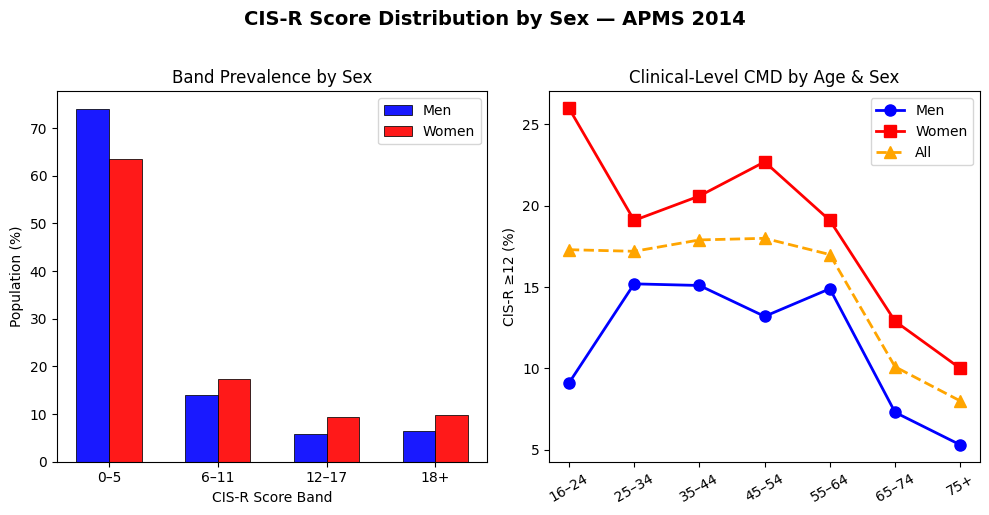

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('CIS-R Score Distribution by Sex — APMS 2014', fontsize=14, fontweight='bold', y=1.02)

ax = axes[0]
x = np.arange(4); w = 0.3
for i, (sex, col) in enumerate([('Men', 'blue'), ('Women', 'red')]):
    vals = [cisr_for(sex)['All'].iloc[b] for b in range(4)]
    ax.bar(x + i*w, vals, w, label=sex, color=col, alpha=0.9, edgecolor='black', lw=0.6)
ax.set_xticks(x + w/2); ax.set_xticklabels(BANDS)
ax.set_xlabel('CIS-R Score Band'); ax.set_ylabel('Population (%)')
ax.set_title('Band Prevalence by Sex'); ax.legend()

ax = axes[1]
cisr_12_men   = [cisr_men[a].iloc[2] + cisr_men[a].iloc[3]   for a in AGES[:-1]]
cisr_12_women = [cisr_women[a].iloc[2] + cisr_women[a].iloc[3] for a in AGES[:-1]]
cisr_12_all   = [cisr_all[a].iloc[2]  + cisr_all[a].iloc[3]   for a in AGES[:-1]]
xs = np.arange(7)
ax.plot(xs, cisr_12_men,   'o-', color='blue',   lw=2, ms=8, label='Men')
ax.plot(xs, cisr_12_women, 's-', color='red',    lw=2, ms=8, label='Women')
ax.plot(xs, cisr_12_all,   '^--',color='orange', lw=2, ms=8, label='All')
ax.fill_between(xs, cisr_12_men, cisr_12_women, alpha=0.08, color='white')
ax.set_xticks(xs); ax.set_xticklabels(AGES[:-1], rotation=30)
ax.set_ylabel('CIS-R ≥12 (%)'); ax.set_title('Clinical-Level CMD by Age & Sex')
ax.legend()

plt.tight_layout(); plt.show()

## CMD Disorder Breakdown (Anxiety Subscales)

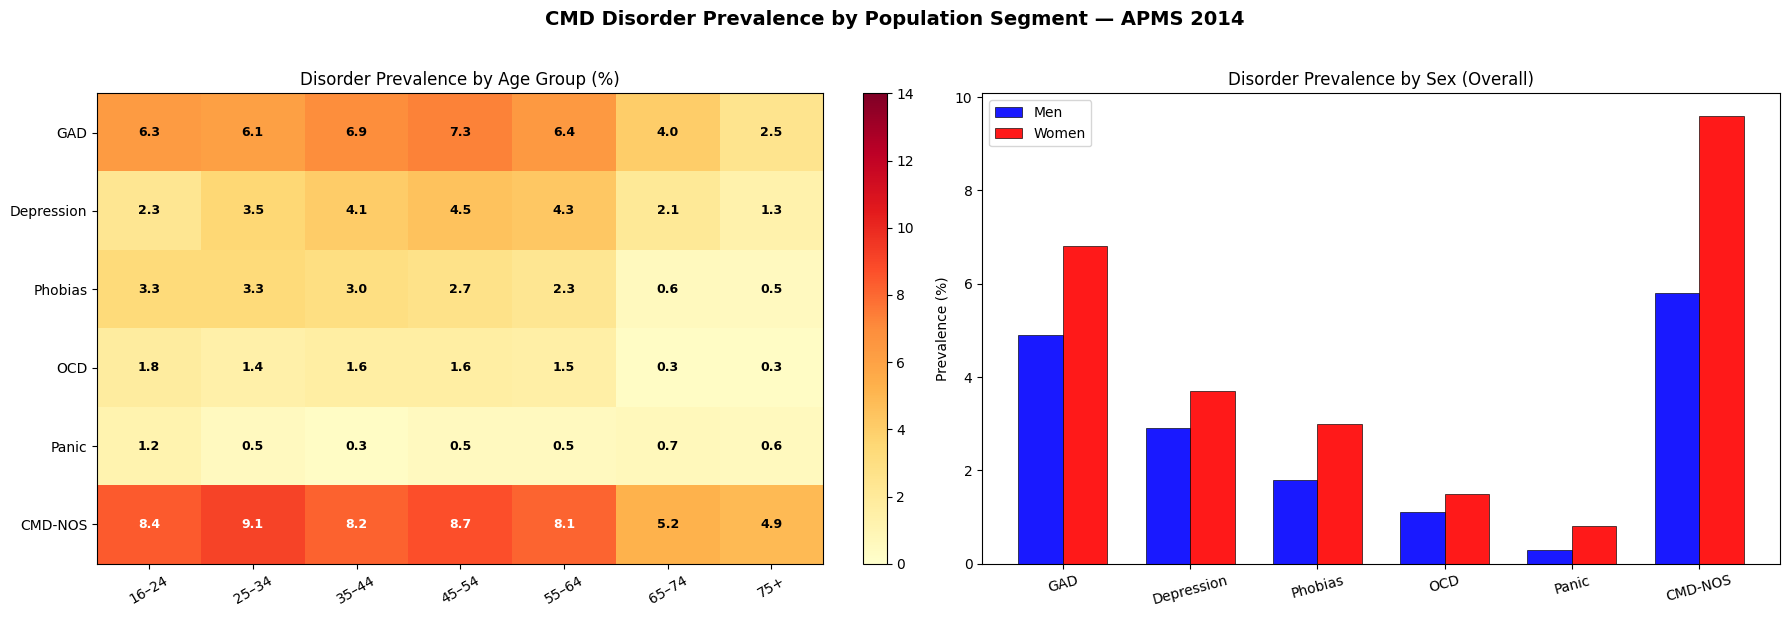

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('CMD Disorder Prevalence by Population Segment — APMS 2014',
             fontsize=14, fontweight='bold', y=1.02)
ax = axes[0]
mat = cmd_age.iloc[:6, :7].values.astype(float)
im  = ax.imshow(mat, cmap='YlOrRd', aspect='auto', vmin=0, vmax=14)
ax.set_xticks(range(7)); ax.set_xticklabels(AGES[:-1], rotation=30)
ax.set_yticks(range(6)); ax.set_yticklabels(DISORDERS[:6])
for i in range(6):
    for j in range(7):
        ax.text(j, i, f'{mat[i,j]:.1f}', ha='center', va='center',
                fontsize=9, color='black' if mat[i,j] < 8 else 'white', fontweight='bold')
ax.set_title('Disorder Prevalence by Age Group (%)'); plt.colorbar(im, ax=ax, fraction=0.04)

ax = axes[1]
x = np.arange(6); w = 0.35
men_vals   = cmd_men.iloc[:6, -1].values
women_vals = cmd_women.iloc[:6, -1].values
ax.bar(x - w/2, men_vals,   w, label='Men',   color='blue', alpha=0.9, edgecolor='black', lw=0.5)
ax.bar(x + w/2, women_vals, w, label='Women', color='red',  alpha=0.9, edgecolor='black', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(DISORDERS[:6], rotation=15)
ax.set_ylabel('Prevalence (%)'); ax.set_title('Disorder Prevalence by Sex (Overall)')
ax.legend()

plt.tight_layout(); plt.show()

## Distribution Across Social Segments

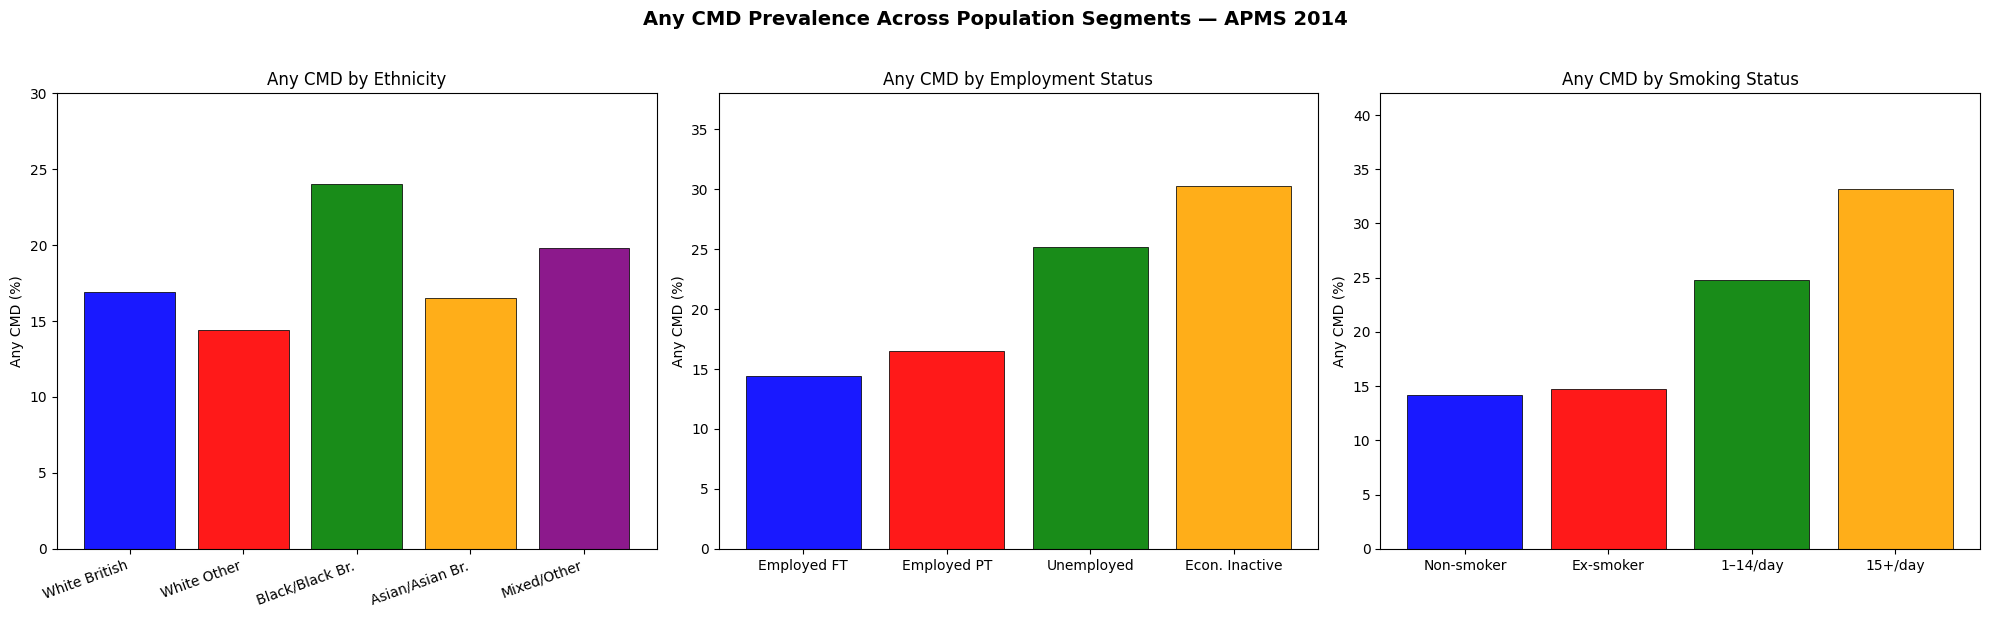

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Any CMD Prevalence Across Population Segments — APMS 2014',
             fontsize=14, fontweight='bold', y=1.02)

ax = axes[0]
any_cmd_eth = cmd_eth.loc['Any CMD'].values
bars = ax.bar(ETH, any_cmd_eth, color=['blue','red','green','orange','purple'], edgecolor='black', lw=0.6, alpha=0.9)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10, color='white')
ax.set_xticklabels(ETH, rotation=20, ha='right'); ax.set_ylabel('Any CMD (%)')
ax.set_title('Any CMD by Ethnicity'); ax.set_ylim(0, 30)

ax = axes[1]
any_cmd_emp = cmd_emp.loc['Any CMD'].values
bars = ax.bar(EMP_GROUPS, any_cmd_emp, color=['blue','red','green','orange','purple'], edgecolor='black', lw=0.6, alpha=0.9)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10, color='white')
ax.set_ylabel('Any CMD (%)'); ax.set_title('Any CMD by Employment Status'); ax.set_ylim(0, 38)

ax = axes[2]
any_cmd_smoke = cmd_smoke.loc['Any CMD'].values
bars = ax.bar(SMOKE_GROUPS, any_cmd_smoke, color=['blue','red','green','orange','purple'], edgecolor='black', lw=0.6, alpha=0.9)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10, color='white')
ax.set_ylabel('Any CMD (%)'); ax.set_title('Any CMD by Smoking Status'); ax.set_ylim(0, 42)

plt.tight_layout(); plt.show()

##  Disorder-Specific Profile

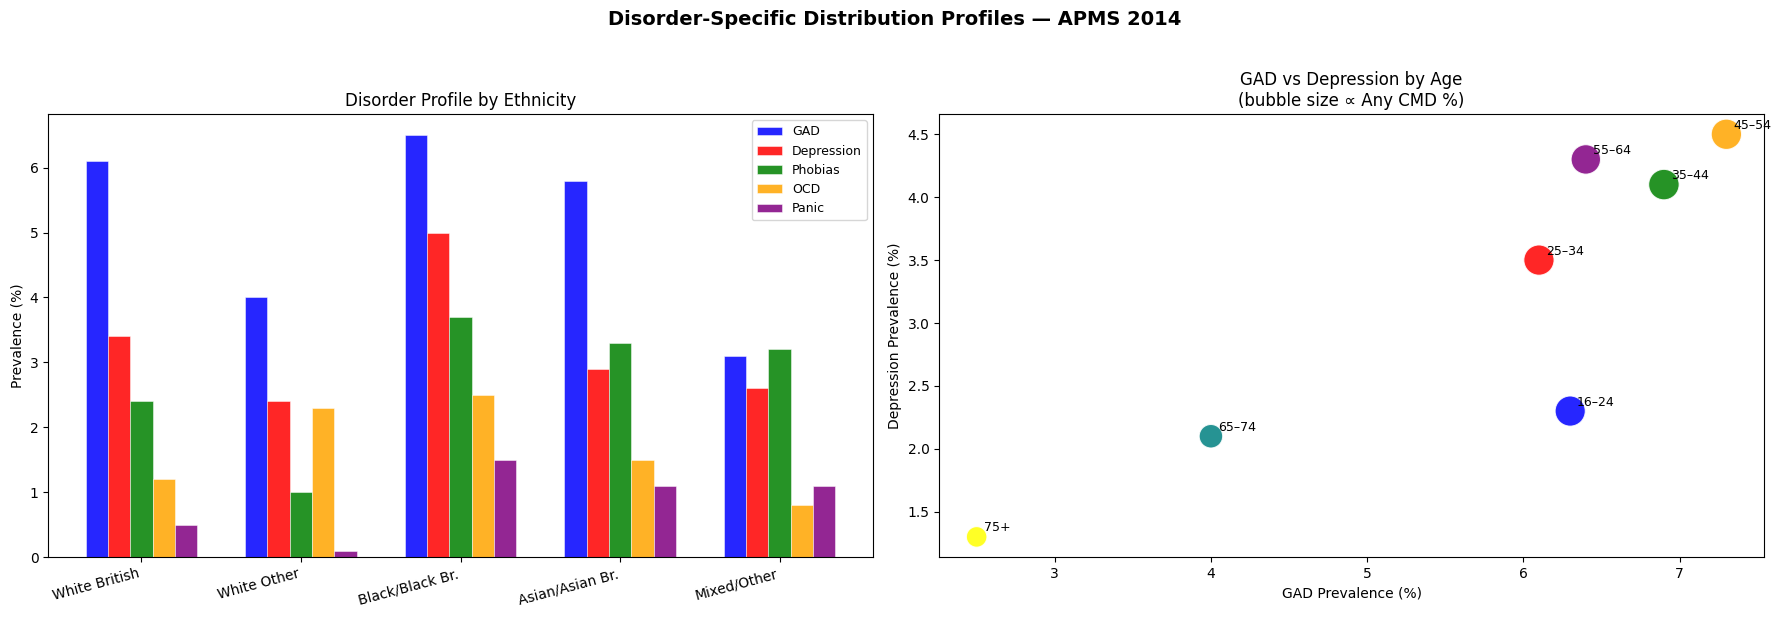

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Disorder-Specific Distribution Profiles — APMS 2014',
             fontsize=14, fontweight='bold', y=1.02)

ax = axes[0]
x = np.arange(5); w = 0.14
dis_to_plot = DISORDERS[:5]
disorder_colors = ['blue', 'red', 'green', 'orange', 'purple']
for di, dis in enumerate(dis_to_plot):
    vals = cmd_eth.loc[dis].values
    ax.bar(x + di*w, vals, w, label=dis, color=disorder_colors[di], alpha=0.85, edgecolor='white', lw=0.4)
ax.set_xticks(x + w*2); ax.set_xticklabels(ETH, rotation=15, ha='right')
ax.set_ylabel('Prevalence (%)'); ax.set_title('Disorder Profile by Ethnicity')
ax.legend(fontsize=9)


ax = axes[1]
gad  = cmd_age.loc['GAD',    AGES[:-1]].values
depr = cmd_age.loc['Depression', AGES[:-1]].values
anycmd = cmd_age.loc['Any CMD',  AGES[:-1]].values
age_colors = ['blue', 'red', 'green', 'orange', 'purple', 'teal', 'yellow']
sc = ax.scatter(gad, depr, s=anycmd*25, c=age_colors, alpha=0.85, edgecolors='white', lw=0.8)
for i, ag in enumerate(AGES[:-1]):
    ax.annotate(ag, (gad[i], depr[i]), xytext=(5,4), textcoords='offset points', fontsize=9)
ax.set_xlabel('GAD Prevalence (%)'); ax.set_ylabel('Depression Prevalence (%)')
ax.set_title('GAD vs Depression by Age\n(bubble size \u221D Any CMD %)')

plt.tight_layout(); plt.show()

## Regional Distribution

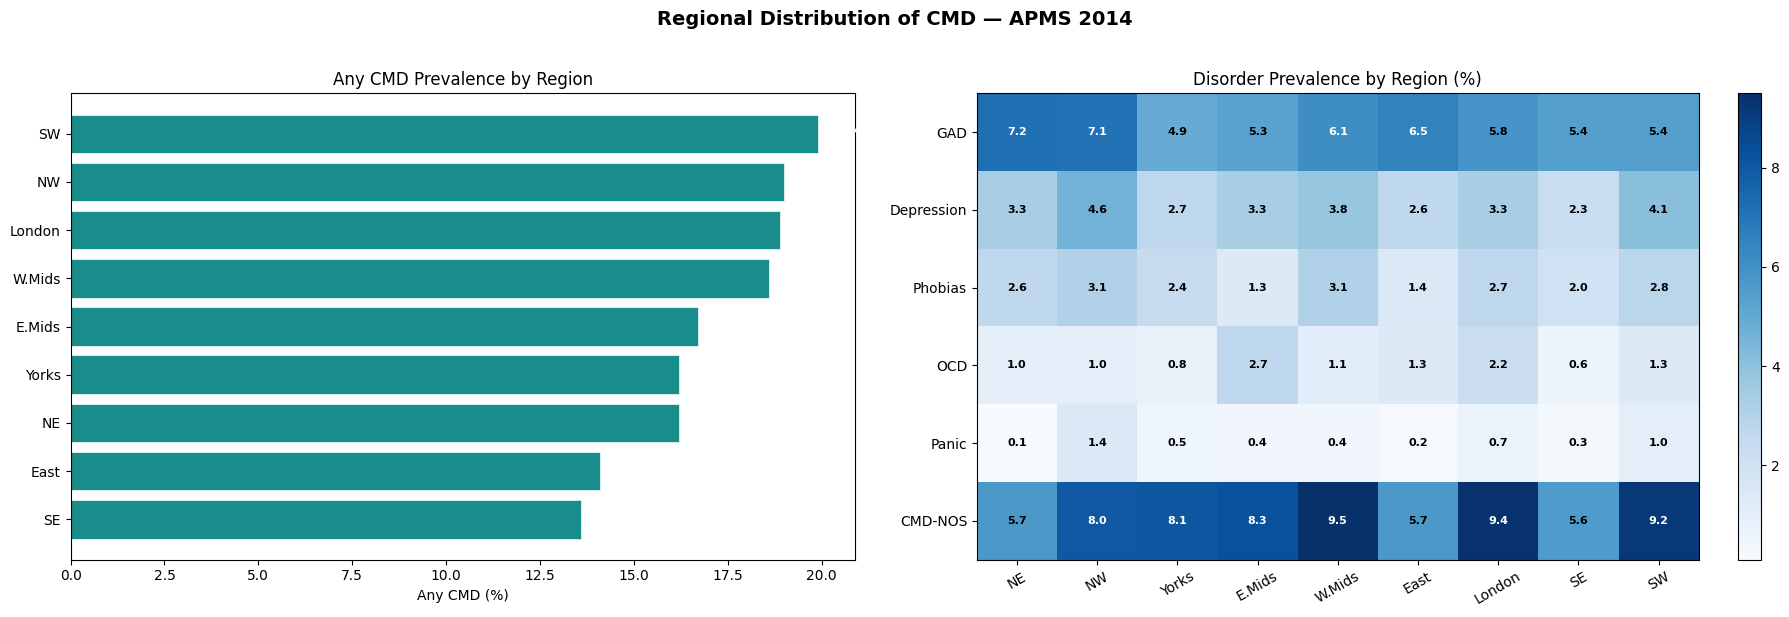

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Regional Distribution of CMD — APMS 2014', fontsize=14, fontweight='bold', y=1.02)

ax = axes[0]
region_any = cmd_region.loc['Any CMD'].sort_values(ascending=True)
bars = ax.barh(region_any.index, region_any.values, color='teal', edgecolor='white', lw=0.5, alpha=0.9)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10, color='white')
ax.set_xlabel('Any CMD (%)'); ax.set_title('Any CMD Prevalence by Region')

ax = axes[1]
mat = cmd_region.iloc[:6].values.astype(float)
im  = ax.imshow(mat, cmap='Blues', aspect='auto')
ax.set_xticks(range(9)); ax.set_xticklabels(REGIONS, rotation=30)
ax.set_yticks(range(6)); ax.set_yticklabels(DISORDERS[:6])
for i in range(6):
    for j in range(9):
        ax.text(j, i, f'{mat[i,j]:.1f}', ha='center', va='center', fontsize=8,
                color='black' if mat[i,j] < 6 else 'white', fontweight='bold')
ax.set_title('Disorder Prevalence by Region (%)')
plt.colorbar(im, ax=ax, fraction=0.03)

plt.tight_layout(); plt.show()

##  QQ Plots (CIS-R vs Theoretical Distributions)

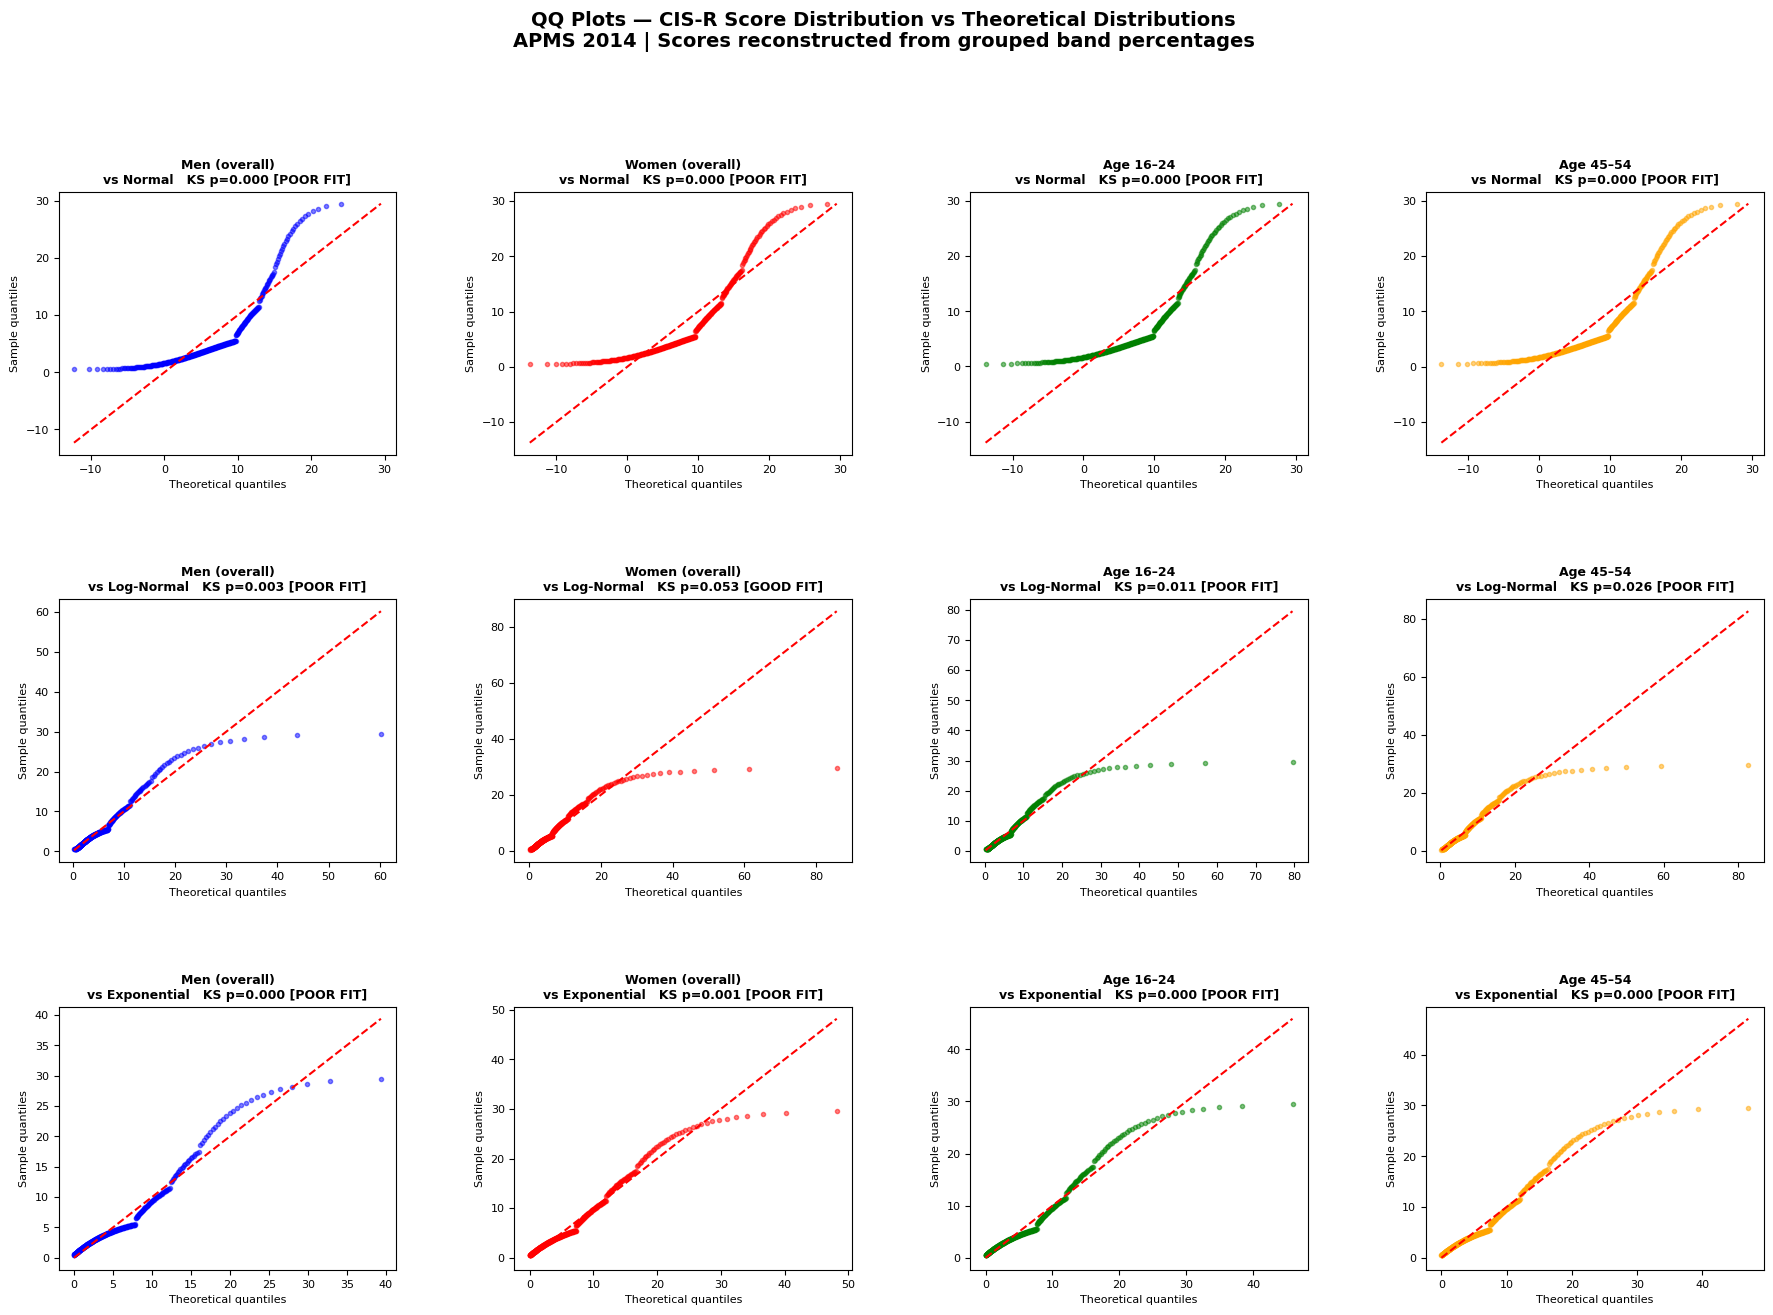


Interpretation:
  • Points close to red line = good fit
  • KS p > 0.05 = cannot reject that distribution
  • CIS-R is heavily right-skewed → Log-Normal fits better than Normal


In [15]:
import matplotlib.gridspec as gridspec

def qq_plot(ax, band_pcts, label, color, dist='norm'):
    obs  = reconstruct_obs(band_pcts)
    n    = len(obs)
    prbs = (np.arange(1, n+1) - 0.5) / n

    if dist == 'norm':
        mu, sd = np.mean(obs), np.std(obs)
        theo   = stats.norm.ppf(prbs, mu, sd)
        ks, p  = stats.kstest(obs, lambda x: stats.norm.cdf(x, mu, sd))
        dname  = 'Normal'
    elif dist == 'lognorm':
        s, _, sc = stats.lognorm.fit(obs, floc=0)
        theo     = stats.lognorm.ppf(prbs, s, scale=sc)
        ks, p    = stats.kstest(obs, lambda x: stats.lognorm.cdf(x, s, scale=sc))
        dname    = 'Log-Normal'
    elif dist == 'expon':
        sc    = np.mean(obs)
        theo  = stats.expon.ppf(prbs, scale=sc)
        ks, p = stats.kstest(obs, lambda x: stats.expon.cdf(x, scale=sc))
        dname = 'Exponential'

    ax.scatter(theo, obs, s=9, alpha=0.5, color=color)
    lo, hi = min(theo.min(), obs.min()), max(theo.max(), obs.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
    fit = 'GOOD FIT' if p > 0.05 else 'POOR FIT'
    ax.set_title(f'{label}\nvs {dname}   KS p={p:.3f} [{fit}]',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Theoretical quantiles', fontsize=8)
    ax.set_ylabel('Sample quantiles',      fontsize=8)
    ax.tick_params(labelsize=8)

fig = plt.figure(figsize=(22, 14))
fig.suptitle('QQ Plots — CIS-R Score Distribution vs Theoretical Distributions\n'
             'APMS 2014 | Scores reconstructed from grouped band percentages',
             fontsize=14, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 4, hspace=0.55, wspace=0.35)

groups = [
    ('Men (overall)',   cisr_men['All'].values,   'blue'),
    ('Women (overall)', cisr_women['All'].values, 'red'),
    ('Age 16–24',       cisr_all['16–24'].values,'green'),
    ('Age 45–54',       cisr_all['45–54'].values, 'orange'),
]

for row, dist in enumerate(['norm', 'lognorm', 'expon']):
    for col, (lbl, pcts, col_c) in enumerate(groups):
        ax = fig.add_subplot(gs[row, col])
        qq_plot(ax, pcts, lbl, col_c, dist=dist)

plt.show()
print('\nInterpretation:')
print('  • Points close to red line = good fit')
print('  • KS p > 0.05 = cannot reject that distribution')
print('  • CIS-R is heavily right-skewed → Log-Normal fits better than Normal')

## Temporal Trend

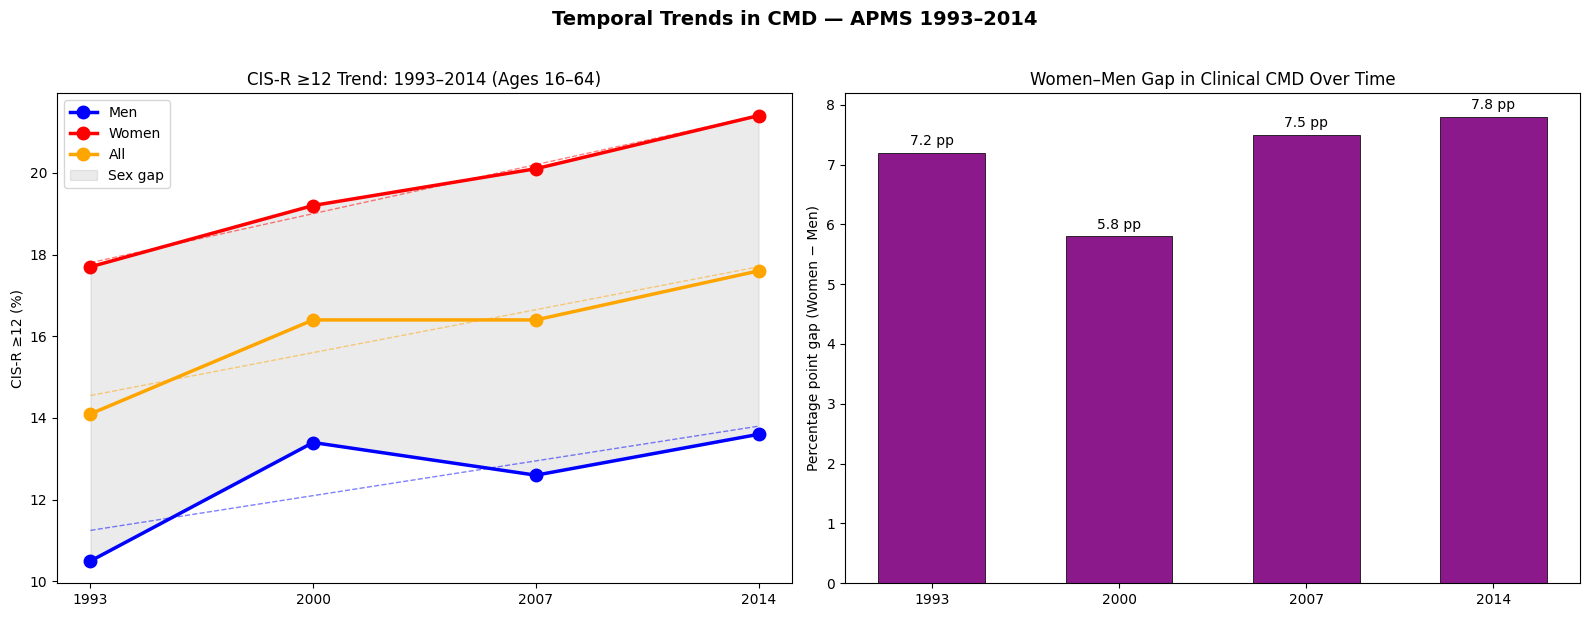

In [16]:
years = [1993, 2000, 2007, 2014]

trend_data = {
    'Men'   : [10.5, 13.4, 12.6, 13.6],
    'Women' : [17.7, 19.2, 20.1, 21.4],
    'All'   : [14.1, 16.4, 16.4, 17.6],
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Temporal Trends in CMD — APMS 1993–2014', fontsize=14, fontweight='bold', y=1.02)

ax = axes[0]
for (sex, vals), col in zip(trend_data.items(), ['blue', 'red', 'orange']):
    ax.plot(years, vals, 'o-', color=col, lw=2.5, ms=9, label=sex)
    z = np.polyfit(years, vals, 1)
    ax.plot(years, np.poly1d(z)(years), '--', color=col, lw=1, alpha=0.5)
ax.fill_between(years, trend_data['Men'], trend_data['Women'], alpha=0.08, color='black',
                label='Sex gap')
ax.set_xticks(years); ax.set_ylabel('CIS-R ≥12 (%)'); ax.legend()
ax.set_title('CIS-R ≥12 Trend: 1993–2014 (Ages 16–64)')


ax = axes[1]
gap = [w - m for m, w in zip(trend_data['Men'], trend_data['Women'])]
bars = ax.bar(years, gap, color='purple', width=4, edgecolor='black', lw=0.6, alpha=0.9)
ax.bar_label(bars, fmt='%.1f pp', padding=3, fontsize=10, color='black')
ax.set_xticks(years); ax.set_ylabel('Percentage point gap (Women − Men)')
ax.set_title('Women–Men Gap in Clinical CMD Over Time')
plt.tight_layout(); plt.show()

## Benefit Status

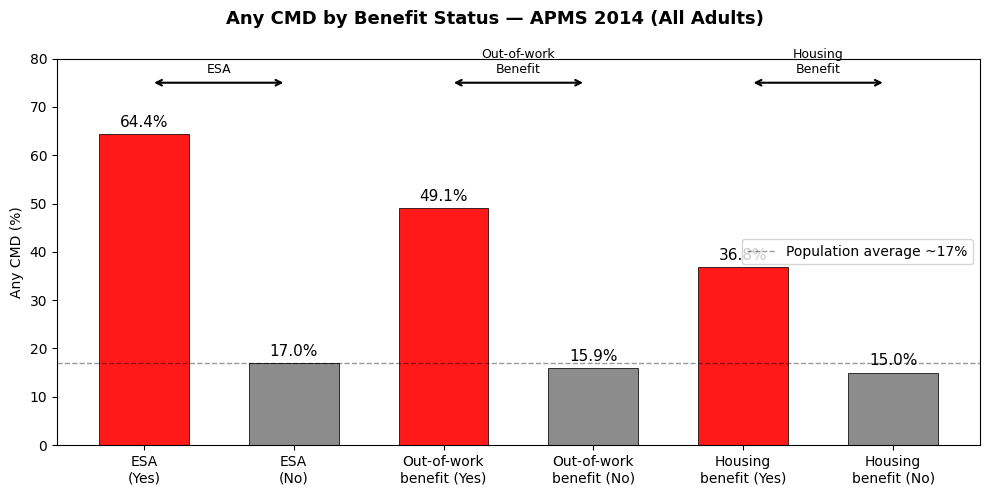

In [17]:
_b = raw['cmd_benefit']

benefit_labels = ['ESA\n(Yes)', 'ESA\n(No)', 'Out-of-work\nbenefit (Yes)',
                  'Out-of-work\nbenefit (No)', 'Housing\nbenefit (Yes)', 'Housing\nbenefit (No)']
any_cmd_benefit = [64.4, 17.0, 49.1, 15.9, 36.8, 15.0]

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Any CMD by Benefit Status — APMS 2014 (All Adults)', fontsize=13, fontweight='bold')
colors_b = ['red' if 'Yes' in l else 'grey' for l in benefit_labels]
bars = ax.bar(benefit_labels, any_cmd_benefit, color=colors_b, edgecolor='black', lw=0.6, alpha=0.9, width=0.6)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11, color='black')
ax.set_ylabel('Any CMD (%)')
ax.axhline(17.0, color='black', linestyle='--', linewidth=1, alpha=0.4, label='Population average ~17%')
ax.legend(); ax.set_ylim(0, 80)

for x_pos, label in [(0.5, 'ESA'), (2.5, 'Out-of-work\nBenefit'), (4.5, 'Housing\nBenefit')]:
    ax.annotate('', xy=(x_pos+0.45, 75), xytext=(x_pos-0.45, 75),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.text(x_pos, 77, label, ha='center', fontsize=9, color='black')

plt.tight_layout(); plt.show()

##  Severity Gradient Heatmap

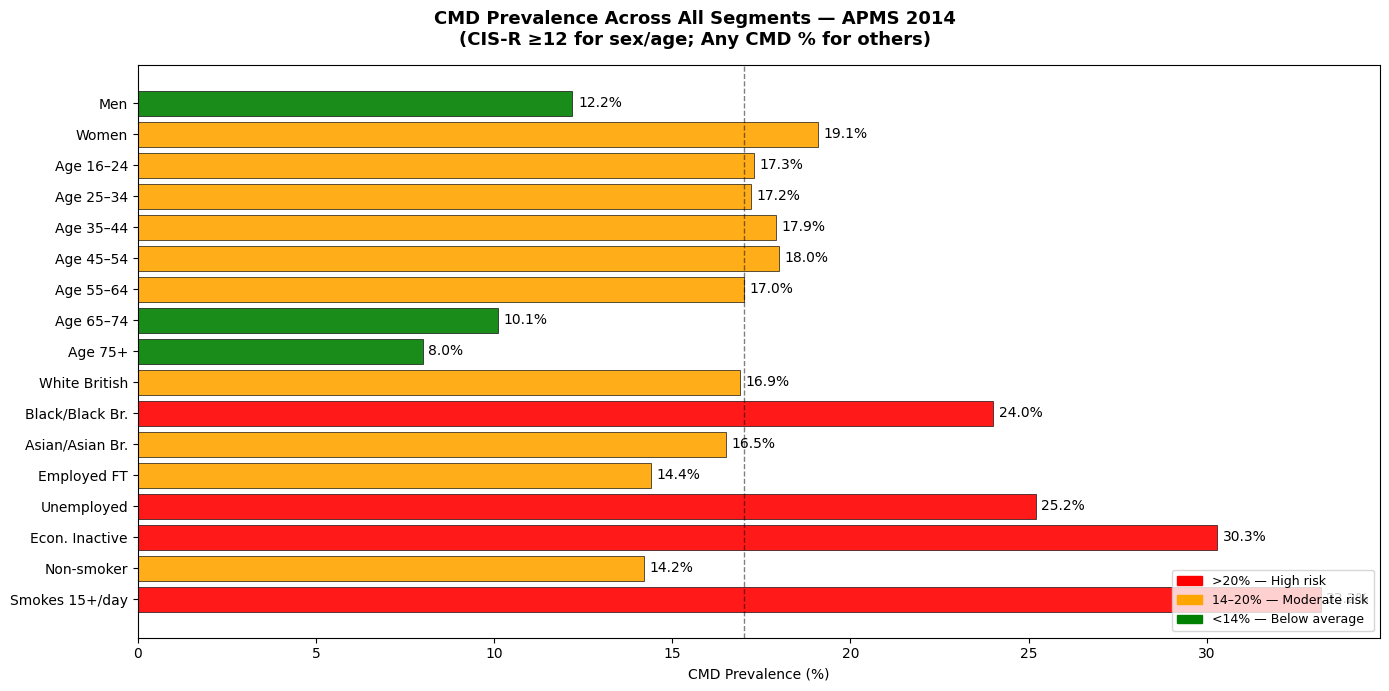

In [18]:
import matplotlib.patches as mpatches
summary_rows = [
    ('Men',               cisr_men['All'].iloc[2]   + cisr_men['All'].iloc[3]),
    ('Women',             cisr_women['All'].iloc[2] + cisr_women['All'].iloc[3]),
    ('Age 16–24',         cisr_all['16–24'].iloc[2] + cisr_all['16–24'].iloc[3]),
    ('Age 25–34',         cisr_all['25–34'].iloc[2] + cisr_all['25–34'].iloc[3]),
    ('Age 35–44',         cisr_all['35–44'].iloc[2] + cisr_all['35–44'].iloc[3]),
    ('Age 45–54',         cisr_all['45–54'].iloc[2] + cisr_all['45–54'].iloc[3]),
    ('Age 55–64',         cisr_all['55–64'].iloc[2] + cisr_all['55–64'].iloc[3]),
    ('Age 65–74',         cisr_all['65–74'].iloc[2] + cisr_all['65–74'].iloc[3]),
    ('Age 75+',           cisr_all['75+'].iloc[2]  + cisr_all['75+'].iloc[3]),
    ('White British',     cmd_eth.loc['Any CMD','White British']),
    ('Black/Black Br.',   cmd_eth.loc['Any CMD','Black/Black Br.']),
    ('Asian/Asian Br.',   cmd_eth.loc['Any CMD','Asian/Asian Br.']),
    ('Employed FT',       cmd_emp.loc['Any CMD','Employed FT']),
    ('Unemployed',        cmd_emp.loc['Any CMD','Unemployed']),
    ('Econ. Inactive',    cmd_emp.loc['Any CMD','Econ. Inactive']),
    ('Non-smoker',        cmd_smoke.loc['Any CMD','Non-smoker']),
    ('Smokes 15+/day',    cmd_smoke.loc['Any CMD','15+/day']),
]

labels = [r[0] for r in summary_rows]
vals   = [r[1] for r in summary_rows]

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('CMD Prevalence Across All Segments — APMS 2014\n(CIS-R ≥12 for sex/age; Any CMD % for others)',
             fontsize=13, fontweight='bold')

colors_v = ['red' if v > 20 else 'orange' if v > 14 else 'green' for v in vals]
bars = ax.barh(labels, vals, color=colors_v, edgecolor='black', lw=0.5, alpha=0.9)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10, color='black')
ax.axvline(17, color='black', linestyle='--', lw=1, alpha=0.5, label='~Overall average 17%')
ax.set_xlabel('CMD Prevalence (%)')
ax.legend(); ax.invert_yaxis()


patches = [
    mpatches.Patch(color='red',    label='>20% — High risk'),
    mpatches.Patch(color='orange', label='14–20% — Moderate risk'),
    mpatches.Patch(color='green',  label='<14% — Below average'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)

plt.tight_layout(); plt.show()

## Summary

In [19]:
print('=' * 65)
print('KEY FINDINGS — APMS 2014 CIS-R Distribution Analysis')
print('=' * 65)

print('\n1. DISTRIBUTION SHAPE')
print('   CIS-R is strongly right-skewed (most people score 0–5).')
print('   Log-Normal fits better than Normal (QQ plots, KS test).')

print('\n2. SEX DIFFERENCES')
m12 = cisr_men['All'].iloc[2]  + cisr_men['All'].iloc[3]
w12 = cisr_women['All'].iloc[2] + cisr_women['All'].iloc[3]
print(f'   Men CIS-R ≥12:   {m12:.1f}%')
print(f'   Women CIS-R ≥12: {w12:.1f}%  (gap = {w12-m12:.1f} pp)')

print('\n3. AGE PATTERN')
for age in ['16–24','45–54','75+']:
    v = cisr_all[age].iloc[2] + cisr_all[age].iloc[3]
    print(f'   Age {age}: {v:.1f}% score CIS-R ≥12')

print('\n4. HIGHEST RISK SEGMENTS (Any CMD)')
for lbl, v in sorted(summary_rows, key=lambda x: -x[1])[:5]:
    print(f'   {lbl:22s}: {v:.1f}%')

print('\n5. DISORDER BREAKDOWN (All adults)')
for d in DISORDERS[:6]:
    print(f'   {d:12s}: {cmd_age.loc[d, "All"]:.1f}%')

print('\n6. TEMPORAL TREND')
print('   Women: 17.7% (1993) → 21.4% (2014)  [+3.7 pp]')
print('   Men:   10.5% (1993) → 13.6% (2014)  [+3.1 pp]')
print('   Sex gap has widened over 20 years.')

KEY FINDINGS — APMS 2014 CIS-R Distribution Analysis

1. DISTRIBUTION SHAPE
   CIS-R is strongly right-skewed (most people score 0–5).
   Log-Normal fits better than Normal (QQ plots, KS test).

2. SEX DIFFERENCES
   Men CIS-R ≥12:   12.2%
   Women CIS-R ≥12: 19.1%  (gap = 6.9 pp)

3. AGE PATTERN
   Age 16–24: 17.3% score CIS-R ≥12
   Age 45–54: 18.0% score CIS-R ≥12
   Age 75+: 8.0% score CIS-R ≥12

4. HIGHEST RISK SEGMENTS (Any CMD)
   Smokes 15+/day        : 33.2%
   Econ. Inactive        : 30.3%
   Unemployed            : 25.2%
   Black/Black Br.       : 24.0%
   Women                 : 19.1%

5. DISORDER BREAKDOWN (All adults)
   GAD         : 5.9%
   Depression  : 3.3%
   Phobias     : 2.4%
   OCD         : 1.3%
   Panic       : 0.6%
   CMD-NOS     : 7.8%

6. TEMPORAL TREND
   Women: 17.7% (1993) → 21.4% (2014)  [+3.7 pp]
   Men:   10.5% (1993) → 13.6% (2014)  [+3.1 pp]
   Sex gap has widened over 20 years.
